---
## 1. Setup

Mount Google Drive and download the DeepFashion2 dataset.


In [ ]:
# ============================================================
# 1A: MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

SHARED_FOLDER = "/content/drive/MyDrive"
print(f" Drive mounted. Listing top-level Drive contents:")
if os.path.exists(SHARED_FOLDER):
    for item in os.listdir(SHARED_FOLDER)[:20]:
        print(f"   - {item}")
else:
    print(f" {SHARED_FOLDER} not found")


Mounted at /content/drive
📂 Drive mounted. Listing top-level Drive contents:
   - Untitled document (189).gdoc
   - Untitled document (188).gdoc
   - Untitled document (187).gdoc
   - Untitled document (186).gdoc
   - Untitled document (185).gdoc
   - Untitled document (184).gdoc
   - Untitled document (183).gdoc
   - Untitled document (182).gdoc
   - Untitled presentation (8).gslides
   - Untitled document (181).gdoc
   - Chess infograph-4.pdf
   - Untitled document (180).gdoc
   - Tangerine stuff.gdoc
   - Untitled document (179).gdoc
   - Untitled document (178).gdoc
   - Untitled document (177).gdoc
   - Untitled document (176).gdoc
   - Untitled presentation (7).gslides
   - Untitled document (175).gdoc
   - LA stuff.gdoc


In [ ]:
# ============================================================
# 1B: DOWNLOAD DEEPFASHION2 DATASET
# ============================================================
import gdown
import glob

DATASET_PATH = "/content/deepfashion2_dataset"
DF2_FOLDER_ID = "1pyOqjVM5qMY0LrFcT7Vz0PBh4_n5Buce"  # DeepFashion2 folder ID

if not os.path.exists(DATASET_PATH):
    os.makedirs(DATASET_PATH)
    print(" Downloading DeepFashion2 dataset...")
    gdown.download_folder(id=DF2_FOLDER_ID, output=DATASET_PATH, quiet=False)
else:
    print(f" Dataset already exists at {DATASET_PATH}")

# Unzip if needed
password = "2019Deepfashion2**"
zip_files = glob.glob(os.path.join(DATASET_PATH, "*.zip"))
if zip_files:
    for zf in zip_files:
        output_dir = os.path.splitext(zf)[0]
        print(f" Unzipping {os.path.basename(zf)}...")
        !unzip -n -P "{password}" "{zf}" -d "{output_dir}"
    print(" Unzipping complete!")
else:
    print(" No zip files to extract (already done or data is unzipped)")

⬇️ Downloading DeepFashion2 dataset...


Retrieving folder contents


Processing file 1zm0bDPbBnOKuDAXTln9fXv0yRvXpct4Y Copy of json_for_validation.zip
Processing file 1SxOr_3CFSW0CrNMw00I0-GFX5e7Krft1 Copy of test.zip
Processing file 1BvaI3b2wFn40tUBy0QJAwNOcFwwXMpe6 Copy of train.zip
Processing file 1t7hhCWYyEtgNYeqmo-T5eeGsM1NHNzmQ Copy of validation.zip
Processing file 1nT2HWMssPYlUDaJBnN6fNW5f_rhTKD1R Untitled0.ipynb


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1zm0bDPbBnOKuDAXTln9fXv0yRvXpct4Y
From (redirected): https://drive.google.com/uc?id=1zm0bDPbBnOKuDAXTln9fXv0yRvXpct4Y&confirm=t&uuid=669ad584-9a15-4b66-99be-80fd301d51b7
To: /content/deepfashion2_dataset/Copy of json_for_validation.zip
100%|██████████| 14.9M/14.9M [00:00<00:00, 45.0MB/s]


FileURLRetrievalError: Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1SxOr_3CFSW0CrNMw00I0-GFX5e7Krft1

but Gdown can't. Please check connections and permissions.

In [ ]:
# ============================================================
# 1BA (FIXED): COPY DATASET FROM MY DRIVE FOLDER RUN IF IN DRIVE
# ============================================================
import os, shutil, glob

DATASET_PATH = "/content/deepfashion2_dataset"
MY_DRIVE_DATASET = "/content/drive/MyDrive/DeepFashion2"

os.makedirs(DATASET_PATH, exist_ok=True)

# Only copy the zips we actually need for training — skip test.zip (3.3 GB, useless for our task)
NEEDED_ZIPS = ["train.zip", "validation.zip", "json_for_validation.zip"]

for f in NEEDED_ZIPS:
    src = os.path.join(MY_DRIVE_DATASET, f)
    dst = os.path.join(DATASET_PATH, f)
    if not os.path.exists(src):
        print(f"  {f} not found in {MY_DRIVE_DATASET}")
        continue
    if not os.path.exists(dst):
        size_gb = os.path.getsize(src) / 1e9
        print(f" Copying {f} ({size_gb:.2f} GB)...")
        shutil.copy(src, dst)
    else:
        print(f"  {f} already in /content/")

# Unzip
password = "2019Deepfashion2**"
for zf in glob.glob(os.path.join(DATASET_PATH, "*.zip")):
    output_dir = os.path.splitext(zf)[0]
    if not os.path.exists(output_dir):
        print(f"\n Unzipping {os.path.basename(zf)}...")
        !unzip -n -P "{password}" "{zf}" -d "{output_dir}"

print("\n Done. Contents of /content/deepfashion2_dataset/:")
for item in sorted(os.listdir(DATASET_PATH)):
    print(f"   - {item}")

Streaming output truncated to the last 5000 lines.
  inflating: /content/deepfashion2_dataset/validation/validation/image/006696.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006591.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006587.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006563.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006523.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006476.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006455.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006413.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006387.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006372.jpg  
  inflating: /content/deepfashion2_dataset/validation/validation/image/006351.jpg  
  inflating: /content/dee

---
## 2. Dataset Prep

Convert DeepFashion2 raw annotations to COCO format and repair polygon nesting.
This matches the prep done in the main 3-model notebook so SegFormer trains on
the same processed data.


In [ ]:
# ============================================================
# 2A: FOLDER RENAMES (strip "Copy of" prefixes from gdown)
# ============================================================
base = "/content/deepfashion2_dataset"

renames = {
    "Copy of train": "train",
    "Copy of validation": "validation",
    "Copy of test": "test",
    "Copy of json_for_validation": "json_for_validation",
}

for old, new in renames.items():
    op = os.path.join(base, old)
    np_ = os.path.join(base, new)
    if os.path.exists(op) and not os.path.exists(np_):
        os.rename(op, np_)
        print(f" Renamed '{old}' → '{new}'")
    elif os.path.exists(np_):
        print(f" '{new}' already exists, skipping")


ℹ️ 'train' already exists, skipping
ℹ️ 'validation' already exists, skipping
ℹ️ 'json_for_validation' already exists, skipping


In [ ]:
# ============================================================
# 2AB: FOLDER RENAMES (no-op if zips were not 'Copy of' prefixed) RUN IF RAN 1BA
# ============================================================
import os

base = "/content/deepfashion2_dataset"

# These renames are only needed if you downloaded from the public Drive folder
# (where files were named "Copy of train.zip" etc). With your own Drive copy,
# the folders are already named correctly.
renames = {
    "Copy of train": "train",
    "Copy of validation": "validation",
    "Copy of test": "test",
    "Copy of json_for_validation": "json_for_validation",
}

renamed = 0
for old, new in renames.items():
    op = os.path.join(base, old)
    np_ = os.path.join(base, new)
    if os.path.exists(op) and not os.path.exists(np_):
        os.rename(op, np_)
        print(f" Renamed '{old}' → '{new}'")
        renamed += 1

if renamed == 0:
    print(" No 'Copy of' folders to rename — folders already named correctly")

print(f"\nContents of {base}:")
for item in sorted(os.listdir(base)):
    if os.path.isdir(os.path.join(base, item)):
        print(f"    {item}/")

ℹ️  No 'Copy of' folders to rename — folders already named correctly

Contents of /content/deepfashion2_dataset:
   📁 json_for_validation/
   📁 train/
   📁 validation/


In [ ]:
# ============================================================
# 2B: GENERATE COCO JSON FROM RAW ANNOTATIONS
# ============================================================
import json
import cv2
from tqdm import tqdm

CATEGORIES = [
    "short_sleeved_shirt", "long_sleeved_shirt", "short_sleeved_outwear",
    "long_sleeved_outwear", "vest", "sling", "shorts", "trousers",
    "skirt", "short_sleeved_dress", "long_sleeved_dress",
    "vest_dress", "sling_dress",
]

def generate_coco_json(base_dir, subset):
    """Convert DeepFashion2 annotations to COCO format."""
    print(f" Generating COCO JSON for {subset}...")

    img_dir = os.path.join(base_dir, subset, subset, "image")
    anno_dir = os.path.join(base_dir, subset, subset, "annos")
    if not os.path.exists(img_dir):
        img_dir = os.path.join(base_dir, subset, "image")
        anno_dir = os.path.join(base_dir, subset, "annos")

    if not os.path.exists(img_dir) or not os.path.exists(anno_dir):
        print(f" Could not find directories for {subset}")
        return None, None

    print(f"    Images: {img_dir}")
    print(f"    Annos:  {anno_dir}")

    coco = {"images": [], "annotations": [], "categories": []}
    for i, cat in enumerate(CATEGORIES):
        coco["categories"].append({"id": i + 1, "name": cat, "supercategory": "clothes"})

    ann_id = 1
    image_id = 1
    json_files = glob.glob(os.path.join(anno_dir, "*.json"))
    existing_images = set(os.listdir(img_dir))

    for jf in tqdm(json_files, desc=f"Processing {subset}"):
        with open(jf, 'r') as f:
            data = json.load(f)

        fname = os.path.basename(jf).replace(".json", ".jpg")
        if fname not in existing_images:
            continue

        img = cv2.imread(os.path.join(img_dir, fname))
        if img is None:
            continue
        h, w, _ = img.shape

        coco["images"].append({"id": image_id, "file_name": fname,
                               "width": w, "height": h})

        for key, val in data.items():
            if key.startswith('item'):
                x1, y1, x2, y2 = val['bounding_box']
                seg = val.get('segmentation', [])
                coco["annotations"].append({
                    "id": ann_id, "image_id": image_id,
                    "category_id": val['category_id'],
                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                    "segmentation": [seg] if seg else [],
                    "area": (x2 - x1) * (y2 - y1), "iscrowd": 0,
                })
                ann_id += 1
        image_id += 1

    output_path = os.path.join(base_dir, f"{subset}_coco.json")
    with open(output_path, 'w') as f:
        json.dump(coco, f)
    print(f"    Saved: {output_path} ({len(coco['images'])} images, "
          f"{len(coco['annotations'])} annotations)")
    return output_path, img_dir

TRAIN_JSON, TRAIN_IMGS = generate_coco_json(DATASET_PATH, "train")
VAL_JSON,   VAL_IMGS   = generate_coco_json(DATASET_PATH, "validation")


🔄 Generating COCO JSON for train...
   📂 Images: /content/deepfashion2_dataset/train/train/image
   📂 Annos:  /content/deepfashion2_dataset/train/train/annos


Processing train: 100%|██████████| 191961/191961 [03:14<00:00, 987.48it/s] 


   ✅ Saved: /content/deepfashion2_dataset/train_coco.json (191961 images, 312186 annotations)
🔄 Generating COCO JSON for validation...
   📂 Images: /content/deepfashion2_dataset/validation/validation/image
   📂 Annos:  /content/deepfashion2_dataset/validation/validation/annos


Processing validation: 100%|██████████| 32153/32153 [00:33<00:00, 956.64it/s] 


   ✅ Saved: /content/deepfashion2_dataset/validation_coco.json (32153 images, 52490 annotations)


In [ ]:
# ============================================================
# 2C: REPAIR POLYGON NESTING
# ============================================================
def repair_json_nesting(json_path):
    """Fix triple-nested polygons: [[[x,y,...]]] -> [[x,y,...]]"""
    print(f" Repairing {os.path.basename(json_path)}...")
    with open(json_path, 'r') as f:
        data = json.load(f)

    fixed = 0
    for ann in data['annotations']:
        seg = ann.get('segmentation', [])
        if len(seg) > 0 and len(seg[0]) > 0 and isinstance(seg[0][0], list):
            ann['segmentation'] = seg[0]
            fixed += 1

    output_path = json_path.replace(".json", "_repaired.json")
    with open(output_path, 'w') as f:
        json.dump(data, f)
    print(f"   Fixed {fixed} annotations -> {output_path}")
    return output_path

TRAIN_JSON = repair_json_nesting(TRAIN_JSON)
VAL_JSON   = repair_json_nesting(VAL_JSON)

print(f"\n Final paths:")
print(f"   TRAIN_JSON: {TRAIN_JSON}")
print(f"   TRAIN_IMGS: {TRAIN_IMGS}")
print(f"   VAL_JSON:   {VAL_JSON}")
print(f"   VAL_IMGS:   {VAL_IMGS}")


🔧 Repairing train_coco.json...
   Fixed 312186 annotations -> /content/deepfashion2_dataset/train_coco_repaired.json
🔧 Repairing validation_coco.json...
   Fixed 52490 annotations -> /content/deepfashion2_dataset/validation_coco_repaired.json

✅ Final paths:
   TRAIN_JSON: /content/deepfashion2_dataset/train_coco_repaired.json
   TRAIN_IMGS: /content/deepfashion2_dataset/train/train/image
   VAL_JSON:   /content/deepfashion2_dataset/validation_coco_repaired.json
   VAL_IMGS:   /content/deepfashion2_dataset/validation/validation/image


In [ ]:
# Cache the COCO JSONs to Drive — they take 5 min to regenerate otherwise run only once
import shutil
CACHE = "/content/drive/MyDrive/DeepFashion2/processed"
import os
os.makedirs(CACHE, exist_ok=True)
for src in [TRAIN_JSON, VAL_JSON]:
    dst = os.path.join(CACHE, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f" Cached {os.path.basename(src)}")

In [ ]:
# Restore COCO JSONs from cache instead of regenerating
import shutil, os
CACHE = "/content/drive/MyDrive/DeepFashion2/processed"
TRAIN_JSON = "/content/deepfashion2_dataset/train_coco_repaired.json"
VAL_JSON = "/content/deepfashion2_dataset/val_coco_repaired.json"
TRAIN_IMGS = "/content/deepfashion2_dataset/train/train/image"
VAL_IMGS = "/content/deepfashion2_dataset/validation/validation/image"

for f in ["train_coco_repaired.json", "val_coco_repaired.json"]:
    src = os.path.join(CACHE, f)
    dst = os.path.join("/content/deepfashion2_dataset", f)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f" Restored {f}")

✅ Restored train_coco_repaired.json


In [ ]:
# ============================================================
# 2D: LOCK VAL SUBSET FOR CROSS-MODEL COMPARISON
# ============================================================
# This is the manifest Ronald needs for his M2F + SAM evals so the
# cross-model comparison table lines up across all three models.

import json, os
import numpy as np
from pycocotools.coco import COCO

CATEGORIES_2D = [
    "short_sleeved_shirt", "long_sleeved_shirt", "short_sleeved_outwear",
    "long_sleeved_outwear", "vest", "sling", "shorts", "trousers",
    "skirt", "short_sleeved_dress", "long_sleeved_dress",
    "vest_dress", "sling_dress",
]

def select_val_subset(val_json, n_images=500, seed=0):
    """Stratified random subset: ensures every category has reasonable coverage."""
    coco = COCO(val_json)
    rng = np.random.default_rng(seed)

    per_cat_quota = max(10, n_images // (len(CATEGORIES_2D) * 4))
    chosen = set()
    for cat_id in range(1, len(CATEGORIES_2D) + 1):
        anns = coco.loadAnns(coco.getAnnIds(catIds=[cat_id]))
        img_ids = list({a["image_id"] for a in anns})
        rng.shuffle(img_ids)
        for iid in img_ids[:per_cat_quota]:
            chosen.add(int(iid))

    all_ids = list(coco.imgs.keys())
    rng.shuffle(all_ids)
    for iid in all_ids:
        if len(chosen) >= n_images:
            break
        chosen.add(int(iid))

    stems = sorted(os.path.splitext(coco.loadImgs([i])[0]["file_name"])[0] for i in chosen)
    return stems

# Pick the subset
val_stems = select_val_subset(VAL_JSON, n_images=2000, seed=0)

# Save it somewhere Ronald can access
SHARED_DIR = "/content/drive/MyDrive/CS4701"  # ← change if you want a different folder
os.makedirs(SHARED_DIR, exist_ok=True)
manifest_path = os.path.join(SHARED_DIR, "val_subset.json")

with open(manifest_path, "w") as f:
    json.dump({
        "image_id_stems": val_stems,
        "n": len(val_stems),
        "seed": 0,
        "categories_used_for_stratification": CATEGORIES_2D,
    }, f, indent=2)

print(f" Val subset locked: {len(val_stems)} images")
print(f" Manifest saved to: {manifest_path}")

loading annotations into memory...
Done (t=2.87s)
creating index...
index created!
📌 Val subset locked: 2000 images
📁 Manifest saved to: /content/drive/MyDrive/CS4701/val_subset.json

>>> Send Ronald this path: /content/drive/MyDrive/CS4701/val_subset.json
    (he needs to mount your Drive folder or you need to share it with him)


---
## 3. SegFormer Pipeline Definitions

Run these once per session. Defines:
- Augmentation pipelines (parity with Mask2Former: multi-scale resize, hflip, ±10° rotation, brightness/contrast)
- Occlusion-aware semantic mask generation (large polygons written first; smaller occluders win)
- Dataset class
- Median-frequency-balanced class weights
- Layer-wise LR decay param groups
- Dataset-level confusion-matrix mIoU evaluation
- Configurable training loop with class weighting via manual cross-entropy


In [ ]:
# ============================================================
# 3A: INSTALL EXTRA DEPS + IMPORTS
# ============================================================
!pip install -q albumentations

import os, json, time, copy, shutil, datetime, glob
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import cv2
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, PolynomialLR
from torch.utils.data import Dataset, DataLoader

from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils

import albumentations as A
from albumentations.pytorch import ToTensorV2


✅ Imports ready


In [ ]:
# ============================================================
# 3B: CONSTANTS + AUGMENTATION PIPELINES (M2F parity)
# ============================================================
NUM_CLASSES = 14  # 0 = background, 1..13 = clothing
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# CATEGORIES already defined in cell 2B; redefine here in case 3 is run alone
CATEGORIES = [
    "short_sleeved_shirt", "long_sleeved_shirt", "short_sleeved_outwear",
    "long_sleeved_outwear", "vest", "sling", "shorts", "trousers",
    "skirt", "short_sleeved_dress", "long_sleeved_dress",
    "vest_dress", "sling_dress",
]

def get_train_transform(crop_size=512):
    return A.Compose([
        A.OneOf([
            A.SmallestMaxSize(max_size=640),
            A.SmallestMaxSize(max_size=672),
            A.SmallestMaxSize(max_size=704),
            A.SmallestMaxSize(max_size=736),
            A.SmallestMaxSize(max_size=800),
        ], p=1.0),
        A.LongestMaxSize(max_size=1333),
        A.PadIfNeeded(min_height=crop_size, min_width=crop_size,
                      border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0),
        A.RandomCrop(height=crop_size, width=crop_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, border_mode=cv2.BORDER_CONSTANT,
                 fill=0, fill_mask=0, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def get_val_transform(crop_size=512):
    return A.Compose([
        A.LongestMaxSize(max_size=crop_size),
        A.PadIfNeeded(min_height=crop_size, min_width=crop_size,
                      border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


In [ ]:
# ============================================================
# 3C: OCCLUSION-AWARE SEMANTIC MASK GENERATION
# ============================================================
def create_semantic_masks(json_path, output_mask_dir):
    os.makedirs(output_mask_dir, exist_ok=True)
    with open(json_path, "r") as f:
        data = json.load(f)

    img_id_to_anns = {}
    for ann in data["annotations"]:
        img_id_to_anns.setdefault(ann["image_id"], []).append(ann)

    count = 0
    for img_info in tqdm(data["images"], desc="Creating semantic masks"):
        h, w = img_info["height"], img_info["width"]
        label_map = np.zeros((h, w), dtype=np.uint8)

        anns = img_id_to_anns.get(img_info["id"], [])
        # Largest first; later (smaller) writes occlude
        anns_sorted = sorted(anns, key=lambda a: a.get("area", 0), reverse=True)

        for ann in anns_sorted:
            seg = ann.get("segmentation", [])
            if not seg:
                continue
            try:
                rle = mask_utils.frPyObjects(seg, h, w)
                binary_mask = mask_utils.decode(mask_utils.merge(rle))
                label_map[binary_mask > 0] = ann["category_id"]
            except Exception:
                continue

        fname = img_info["file_name"].replace(".jpg", ".png")
        cv2.imwrite(os.path.join(output_mask_dir, fname), label_map)
        count += 1

    print(f"  Created {count} semantic masks in {output_mask_dir}")


In [ ]:
# ============================================================
# 3D: DATASET CLASS
# ============================================================
class DeepFashionSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform,
                 max_samples=None, image_ids=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        mask_files = set(os.listdir(mask_dir))
        self.samples = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.endswith(".jpg"):
                continue
            mask_fname = fname.replace(".jpg", ".png")
            if mask_fname not in mask_files:
                continue
            if image_ids is not None:
                if os.path.splitext(fname)[0] not in image_ids:
                    continue
            self.samples.append((fname, mask_fname))

        if max_samples is not None:
            self.samples = self.samples[:max_samples]

        print(f"  Dataset: {len(self.samples)} pairs from {img_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_fname, mask_fname = self.samples[idx]
        image = np.array(Image.open(os.path.join(self.img_dir, img_fname)).convert("RGB"))
        mask  = np.array(Image.open(os.path.join(self.mask_dir, mask_fname)))
        out = self.transform(image=image, mask=mask)
        return {"pixel_values": out["image"].float(),
                "labels":       out["mask"].long()}


In [ ]:
# ============================================================
# 3E: CLASS WEIGHTS + PARAM GROUPS
# ============================================================
def compute_class_weights(mask_dir, num_classes=NUM_CLASSES,
                          cap=10.0, background_weight=1.0):
    """Median-frequency balancing capped at `cap`x median."""
    pixel_counts = np.zeros(num_classes, dtype=np.int64)
    files = [f for f in os.listdir(mask_dir) if f.endswith(".png")]
    for fname in tqdm(files, desc="Counting pixels per class"):
        m = np.array(Image.open(os.path.join(mask_dir, fname)))
        for c in range(num_classes):
            pixel_counts[c] += int((m == c).sum())

    total = max(int(pixel_counts.sum()), 1)
    freq = pixel_counts / total
    fg_freq = freq[1:]
    median_freq = float(np.median(fg_freq[fg_freq > 0])) if (fg_freq > 0).any() else 1.0

    weights = np.zeros(num_classes, dtype=np.float32)
    weights[0] = background_weight
    for c in range(1, num_classes):
        if freq[c] > 0:
            weights[c] = float(np.clip(median_freq / freq[c], 0.0, cap))
        else:
            weights[c] = cap

    print(f"  Pixel counts: {pixel_counts.tolist()}")
    print(f"  Class weights: {[round(float(w), 3) for w in weights]}")
    return torch.tensor(weights, dtype=torch.float32)


def get_param_groups(model, base_lr, encoder_lr_mult=1.0, weight_decay=0.01):
    """encoder_lr_mult=0.1 = encoder fine-tunes 10x slower than decoder head."""
    enc_decay, enc_no_decay, dec_decay, dec_no_decay = [], [], [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        in_encoder = "segformer.encoder" in name
        no_decay = name.endswith(".bias") or "norm" in name.lower() or "LayerNorm" in name
        if in_encoder and no_decay:
            enc_no_decay.append(p)
        elif in_encoder:
            enc_decay.append(p)
        elif no_decay:
            dec_no_decay.append(p)
        else:
            dec_decay.append(p)
    return [
        {"params": enc_decay,    "lr": base_lr * encoder_lr_mult, "weight_decay": weight_decay},
        {"params": enc_no_decay, "lr": base_lr * encoder_lr_mult, "weight_decay": 0.0},
        {"params": dec_decay,    "lr": base_lr,                   "weight_decay": weight_decay},
        {"params": dec_no_decay, "lr": base_lr,                   "weight_decay": 0.0},
    ]


In [ ]:
# ============================================================
# 3F: EVALUATION (correct dataset-level confusion matrix mIoU)
# ============================================================
def evaluate_segformer(model, val_loader, device, num_classes=NUM_CLASSES):
    """Standard semseg eval: dataset-level confusion matrix → per-class IoU
    → macro mIoU over foreground classes."""
    model.eval()
    inter = np.zeros(num_classes, dtype=np.int64)
    union = np.zeros(num_classes, dtype=np.int64)
    inf_times = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="SegFormer eval", leave=False):
            pv = batch["pixel_values"].to(device, non_blocking=True)
            lb = batch["labels"].to(device, non_blocking=True)

            t0 = time.time()
            outputs = model(pixel_values=pv)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            inf_times.append((time.time() - t0) / pv.shape[0])

            up = F.interpolate(outputs.logits, size=lb.shape[-2:],
                               mode="bilinear", align_corners=False)
            preds = up.argmax(dim=1).cpu().numpy()
            gts = lb.cpu().numpy()

            for c in range(num_classes):
                pc = (preds == c)
                gc = (gts == c)
                inter[c] += int(np.logical_and(pc, gc).sum())
                union[c] += int(np.logical_or(pc, gc).sum())

    per_class = {}
    for c in range(num_classes):
        name = "background" if c == 0 else CATEGORIES[c - 1]
        per_class[name] = (inter[c] / union[c]) if union[c] > 0 else float("nan")

    fg = [v for k, v in per_class.items() if k != "background" and not np.isnan(v)]
    macro_miou = float(np.mean(fg)) if fg else 0.0

    return {
        "macro_miou": macro_miou,
        "per_class_iou": per_class,
        "avg_inference_ms": float(np.mean(inf_times) * 1000) if inf_times else 0.0,
    }


In [ ]:
# ============================================================
# 3G: TRAINING CONFIG + LOOP + SWEEP
# ============================================================
@dataclass
class SegFormerConfig:
    train_imgs: str
    train_masks: str
    val_imgs: str
    val_masks: str
    crop_size: int = 512
    batch_size: int = 8
    num_workers: int = 2
    val_image_ids: Optional[set] = None

    pretrained: str = "nvidia/segformer-b2-finetuned-ade-512-512"

    num_epochs: int = 15
    base_lr: float = 6e-5
    encoder_lr_mult: float = 1.0
    weight_decay: float = 0.01
    lr_schedule: str = "cosine"   # "cosine" | "poly"
    poly_power: float = 1.0
    grad_clip: float = 1.0

    use_class_weights: bool = False
    class_weight_cap: float = 10.0
    background_weight: float = 1.0

    output_dir: str = "/content/output_segformer"
    run_name: str = "default"

    log_every: int = 50
    seed: int = 42


def _build_scheduler(opt, cfg, steps_per_epoch):
    total = cfg.num_epochs * steps_per_epoch
    if cfg.lr_schedule == "cosine":
        return CosineAnnealingLR(opt, T_max=total)
    if cfg.lr_schedule == "poly":
        return PolynomialLR(opt, total_iters=total, power=cfg.poly_power)
    raise ValueError(cfg.lr_schedule)


def train_segformer(cfg):
    torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    run_dir = os.path.join(cfg.output_dir, cfg.run_name)
    os.makedirs(run_dir, exist_ok=True)

    train_ds = DeepFashionSegDataset(cfg.train_imgs, cfg.train_masks,
                                     transform=get_train_transform(cfg.crop_size))
    val_ds   = DeepFashionSegDataset(cfg.val_imgs, cfg.val_masks,
                                     transform=get_val_transform(cfg.crop_size),
                                     image_ids=cfg.val_image_ids)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, drop_last=True, pin_memory=True,
                          persistent_workers=True, prefetch_factor=4)
    val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=True, prefetch_factor=4)

    print(f"⬇️ Loading {cfg.pretrained} ...")
    model = SegformerForSemanticSegmentation.from_pretrained(
        cfg.pretrained, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True
    ).to(device)

    class_weights = None
    if cfg.use_class_weights:
        print("Computing class weights ...")
        class_weights = compute_class_weights(
            cfg.train_masks, cap=cfg.class_weight_cap,
            background_weight=cfg.background_weight,
        ).to(device)

    optimizer = AdamW(get_param_groups(model, cfg.base_lr,
                                       cfg.encoder_lr_mult, cfg.weight_decay))
    scheduler = _build_scheduler(optimizer, cfg, len(train_loader))

    print(f" Run '{cfg.run_name}' | epochs={cfg.num_epochs} crop={cfg.crop_size} "
          f"lr={cfg.base_lr} (enc x{cfg.encoder_lr_mult}) sched={cfg.lr_schedule} "
          f"weighted={cfg.use_class_weights}")

    history, best = [], 0.0
    for epoch in range(cfg.num_epochs):
        model.train()
        running = 0.0
        for i, batch in enumerate(train_loader):
            pv = batch["pixel_values"].to(device, non_blocking=True)
            lb = batch["labels"].to(device, non_blocking=True)

            outputs = model(pixel_values=pv)
            up = F.interpolate(outputs.logits, size=lb.shape[-2:],
                               mode="bilinear", align_corners=False)
            loss = F.cross_entropy(up, lb, weight=class_weights, ignore_index=255)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            scheduler.step()

            running += loss.item()
            if i % cfg.log_every == 0:
                lr_now = max(g["lr"] for g in optimizer.param_groups)
                print(f"  ep {epoch+1}/{cfg.num_epochs} step {i}/{len(train_loader)} "
                      f"loss={loss.item():.4f} lr={lr_now:.2e}")

        avg = running / max(len(train_loader), 1)
        ev = evaluate_segformer(model, val_loader, device)
        miou = ev["macro_miou"]
        print(f"  >> epoch {epoch+1}: train_loss={avg:.4f} val_macro_mIoU={miou:.4f}")

        history.append({"epoch": epoch+1, "train_loss": avg,
                        "macro_miou": miou,
                        "per_class_iou": ev["per_class_iou"]})
        if miou > best:
            best = miou
            model.save_pretrained(run_dir)
            print(f"   saved best to {run_dir} (mIoU={best:.4f})")

            # NEW: also push to Drive every time we save a new best
            DRIVE_BACKUP_DIR = f"/content/drive/MyDrive/model_comparison/segformer_inprogress/{cfg.run_name}"
            try:
                os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)
                shutil.copytree(run_dir, DRIVE_BACKUP_DIR, dirs_exist_ok=True)
                print(f"    also synced to Drive: {DRIVE_BACKUP_DIR}")
            except Exception as e:
                print(f"    Drive sync failed (continuing): {e}")

    with open(os.path.join(run_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)
    cfg_d = {k: (list(v) if isinstance(v, set) else v) for k, v in cfg.__dict__.items()}
    with open(os.path.join(run_dir, "config.json"), "w") as f:
        json.dump(cfg_d, f, indent=2, default=str)

    return {"best_macro_miou": best, "history": history, "run_dir": run_dir}


def sweep(base_cfg, grid):
    """grid is a list of override dicts."""
    results = []
    for i, overrides in enumerate(grid):
        cfg = copy.deepcopy(base_cfg)
        for k, v in overrides.items():
            setattr(cfg, k, v)
        suffix = "_".join(f"{k}={v}" for k, v in overrides.items())
        cfg.run_name = f"sweep{i:02d}__{suffix}"[:120]
        print(f"\n========== Run {i+1}/{len(grid)}: {cfg.run_name} ==========")
        out = train_segformer(cfg)
        results.append({"overrides": overrides,
                        "best_macro_miou": out["best_macro_miou"],
                        "run_dir": out["run_dir"]})
    return results


SUGGESTED_GRID = [
    {},                                                    # baseline
    {"use_class_weights": True},                           # weighted
    {"crop_size": 640},                                    # bigger crop
    {"lr_schedule": "poly"},                               # poly schedule
    {"encoder_lr_mult": 0.1},                              # layer-wise LR decay
    {"base_lr": 1e-4},                                     # higher LR
    {"use_class_weights": True,
     "encoder_lr_mult": 0.1,
     "lr_schedule": "poly"},                               # combo
]


✅ Pipeline ready: SegFormerConfig, train_segformer, sweep, SUGGESTED_GRID


In [ ]:
# ============================================================
# 3H: TIME-BUDGETED DATASET SUBCLASS
# ============================================================
TRAIN_SUBSET = 50_000   # ~780 steps/epoch at batch 64

_real_dataset = DeepFashionSegDataset

class _SubsampledTrainDataset(DeepFashionSegDataset):
    def __init__(self, img_dir, mask_dir, transform,
                 max_samples=None, image_ids=None):
        if image_ids is None and max_samples is None:
            max_samples = TRAIN_SUBSET
        super().__init__(img_dir, mask_dir, transform,
                         max_samples=max_samples, image_ids=image_ids)

import sys
sys.modules[__name__].DeepFashionSegDataset = _SubsampledTrainDataset
print(f"Training capped to {TRAIN_SUBSET:,} images")

✅ Training capped to 50,000 images


---
## 4. Training Runs

### 4.1 — Regenerate semantic masks (occlusion-aware)

One-off, ~5 min. Uses `_v2` paths so your originals (if any) aren't clobbered.


In [ ]:
# ============================================================
# 4.1: REGENERATE MASKS
# ============================================================
TRAIN_MASKS = "/content/deepfashion2_dataset/train_semantic_masks_v2"
VAL_MASKS   = "/content/deepfashion2_dataset/val_semantic_masks_v2"

if not os.path.exists(TRAIN_MASKS) or len(os.listdir(TRAIN_MASKS)) == 0:
    create_semantic_masks(TRAIN_JSON, TRAIN_MASKS)
if not os.path.exists(VAL_MASKS) or len(os.listdir(VAL_MASKS)) == 0:
    create_semantic_masks(VAL_JSON, VAL_MASKS)

print(f"Train masks: {len(os.listdir(TRAIN_MASKS))} | Val masks: {len(os.listdir(VAL_MASKS))}")


Creating semantic masks: 100%|██████████| 191961/191961 [04:35<00:00, 696.75it/s]


  Created 191961 semantic masks in /content/deepfashion2_dataset/train_semantic_masks_v2


Creating semantic masks: 100%|██████████| 32153/32153 [00:44<00:00, 727.46it/s]


  Created 32153 semantic masks in /content/deepfashion2_dataset/val_semantic_masks_v2
✅ Train masks: 191961 | Val masks: 32153


### 4.2 — Smoke test (DO THIS FIRST)

200 train samples × 2 epochs, ~10 min on RTX 6000. Pipeline sanity check.
If loss decreases and mIoU is non-zero, the pipeline is working. Drop
`batch_size` to 4 if it OOMs.


In [ ]:
# ============================================================
# 4.2: SMOKE TEST
# ============================================================
smoke_cfg = SegFormerConfig(
    train_imgs=TRAIN_IMGS, train_masks=TRAIN_MASKS,
    val_imgs=VAL_IMGS,    val_masks=VAL_MASKS,
    num_epochs=2, batch_size=8, crop_size=512,
    base_lr=6e-5, lr_schedule="cosine",
    use_class_weights=False,
    run_name="smoke_test",
    log_every=10,
)

print("SMOKE TEST — 200 train samples, 2 epochs")

class _SmokeDataset(DeepFashionSegDataset):
    def __init__(self, img_dir, mask_dir, transform, max_samples=200, image_ids=None):
        super().__init__(img_dir, mask_dir, transform,
                         max_samples=max_samples, image_ids=image_ids)

import sys
this_module = sys.modules[__name__]
_real_class = this_module.DeepFashionSegDataset
this_module.DeepFashionSegDataset = _SmokeDataset
try:
    smoke_result = train_segformer(smoke_cfg)
    print(f"\nSmoke mIoU: {smoke_result['best_macro_miou']:.4f}")
    print("   (Tiny dataset → low mIoU is expected. We just want it to run.)")
finally:
    this_module.DeepFashionSegDataset = _real_class


🧪 SMOKE TEST — 200 train samples, 2 epochs
  Dataset: 200 pairs from /content/deepfashion2_dataset/train/train/image
  Dataset: 200 pairs from /content/deepfashion2_dataset/validation/validation/image
⬇️ Loading nvidia/segformer-b2-finetuned-ade-512-512 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

...

  ep 1/2 step 0/25 loss=2.6381 lr=5.99e-05
  ep 1/2 step 10/25 loss=2.5539 lr=5.31e-05
  ep 1/2 step 20/25 loss=2.4149 lr=3.75e-05


  >> epoch 1: train_loss=2.4532 val_macro_mIoU=0.0151


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 saved best to /content/output_segformer/smoke_test (mIoU=0.0151)
  ☁️  also synced to Drive: /content/drive/MyDrive/model_comparison/segformer_inprogress/smoke_test
  ep 2/2 step 0/25 loss=2.2354 lr=2.81e-05
  ep 2/2 step 10/25 loss=2.2752 lr=1.09e-05
  ep 2/2 step 20/25 loss=2.2007 lr=9.43e-07


  >> epoch 2: train_loss=2.1888 val_macro_mIoU=0.0131

🧪 Smoke mIoU: 0.0151
   (Tiny dataset → low mIoU is expected. We just want it to run.)


### 4.3 — Full-dataset baseline (~2 hours)

20 epochs, full DeepFashion2 train split, no class weighting.


In [ ]:
# ============================================================
# 4.3: FULL-DATASET BASELINE
# ============================================================
cfg_baseline = SegFormerConfig(
    train_imgs=TRAIN_IMGS, train_masks=TRAIN_MASKS,
    val_imgs=VAL_IMGS,    val_masks=VAL_MASKS,
    num_epochs=8,
    batch_size=64,
    num_workers=12,
    crop_size=512,
    base_lr=1e-4, lr_schedule="cosine",
    use_class_weights=False,
    run_name="full_baseline",
)
result_baseline = train_segformer(cfg_baseline)
print(f"\n Baseline best macro mIoU: {result_baseline['best_macro_miou']:.4f}")

  Dataset: 50000 pairs from /content/deepfashion2_dataset/train/train/image
  Dataset: 32153 pairs from /content/deepfashion2_dataset/validation/validation/image
⬇️ Loading nvidia/segformer-b2-finetuned-ade-512-512 ...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                    
------------------------------+----------+----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([14])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([14, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


🚀 Run 'full_baseline' | epochs=8 crop=512 lr=0.0001 (enc x1.0) sched=cosine weighted=False
  ep 1/8 step 0/781 loss=2.6513 lr=1.00e-04
  ep 1/8 step 50/781 loss=1.3317 lr=1.00e-04
  ep 1/8 step 100/781 loss=1.1471 lr=9.99e-05
  ep 1/8 step 150/781 loss=0.9923 lr=9.99e-05
  ep 1/8 step 200/781 loss=1.1013 lr=9.97e-05
  ep 1/8 step 250/781 loss=0.7808 lr=9.96e-05
  ep 1/8 step 300/781 loss=1.1112 lr=9.94e-05
  ep 1/8 step 350/781 loss=0.9367 lr=9.92e-05
  ep 1/8 step 400/781 loss=0.8115 lr=9.90e-05
  ep 1/8 step 450/781 loss=0.6686 lr=9.87e-05
  ep 1/8 step 500/781 loss=0.8509 lr=9.84e-05
  ep 1/8 step 550/781 loss=0.7675 lr=9.81e-05
  ep 1/8 step 600/781 loss=0.8132 lr=9.77e-05
  ep 1/8 step 650/781 loss=0.7244 lr=9.73e-05
  ep 1/8 step 700/781 loss=0.8168 lr=9.69e-05
  ep 1/8 step 750/781 loss=0.7200 lr=9.65e-05


  >> epoch 1: train_loss=0.9158 val_macro_mIoU=0.2715


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 saved best to /content/output_segformer/full_baseline (mIoU=0.3993)
  ☁️  also synced to Drive: /content/drive/MyDrive/model_comparison/segformer_inprogress/full_baseline
  ep 8/8 step 0/781 loss=0.4164 lr=3.80e-06
  ep 8/8 step 50/781 loss=0.4787 lr=3.33e-06
  ep 8/8 step 100/781 loss=0.4210 lr=2.89e-06
  ep 8/8 step 150/781 loss=0.4628 lr=2.49e-06
  ep 8/8 step 200/781 loss=0.4646 lr=2.11e-06
  ep 8/8 step 250/781 loss=0.4371 lr=1.76e-06
  ep 8/8 step 300/781 loss=0.5321 lr=1.45e-06
  ep 8/8 step 350/781 loss=0.3999 lr=1.16e-06
  ep 8/8 step 400/781 loss=0.3980 lr=9.10e-07
  ep 8/8 step 450/781 loss=0.3617 lr=6.87e-07
  ep 8/8 step 500/781 loss=0.4638 lr=4.95e-07
  ep 8/8 step 550/781 loss=0.6185 lr=3.34e-07
  ep 8/8 step 600/781 loss=0.4101 lr=2.05e-07
  ep 8/8 step 650/781 loss=0.4006 lr=1.07e-07
  ep 8/8 step 700/781 loss=0.5100 lr=4.04e-08
  ep 8/8 step 750/781 loss=0.4403 lr=5.69e-09


  >> epoch 8: train_loss=0.4465 val_macro_mIoU=0.4021


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 saved best to /content/output_segformer/full_baseline (mIoU=0.4021)
  ☁️  also synced to Drive: /content/drive/MyDrive/model_comparison/segformer_inprogress/full_baseline

✅ Baseline best macro mIoU: 0.4021


### 4.4 — Class-weighted run (~2 hours)

Same config + median-frequency-balanced class weights capped at 10×.
The headline rare-category ablation.


In [ ]:
# ============================================================
# 4.4: CLASS-WEIGHTED RUN
# ============================================================
cfg_weighted = SegFormerConfig(
    train_imgs=TRAIN_IMGS, train_masks=TRAIN_MASKS,
    val_imgs=VAL_IMGS,    val_masks=VAL_MASKS,
    num_epochs=8,
    batch_size=64,
    num_workers=12,
    crop_size=512,
    base_lr=1e-4, lr_schedule="cosine",
    use_class_weights=True, class_weight_cap=10.0,
    run_name="full_weighted",
)
result_weighted = train_segformer(cfg_weighted)
print(f"\n Weighted best macro mIoU: {result_weighted['best_macro_miou']:.4f}")

RARE = ["sling", "short_sleeved_outwear", "vest_dress", "sling_dress",
        "long_sleeved_outwear"]
print("\n📊 Rare-category IoU comparison:")
print(f"{'category':<25} {'baseline':>10} {'weighted':>10} {'Δ':>10}")
for cat in RARE:
    b = result_baseline['history'][-1]['per_class_iou'].get(cat, float('nan'))
    w = result_weighted['history'][-1]['per_class_iou'].get(cat, float('nan'))
    delta = (w - b) if (not np.isnan(b) and not np.isnan(w)) else float('nan')
    print(f"{cat:<25} {b:>10.4f} {w:>10.4f} {delta:>+10.4f}")

  Dataset: 50000 pairs from /content/deepfashion2_dataset/train/train/image
  Dataset: 32153 pairs from /content/deepfashion2_dataset/validation/validation/image
⬇️ Loading nvidia/segformer-b2-finetuned-ade-512-512 ...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                    
------------------------------+----------+----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([14])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([14, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Computing class weights ...


Counting pixels per class: 100%|██████████| 191961/191961 [11:07<00:00, 287.58it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 saved best to /content/output_segformer/full_weighted (mIoU=0.3814)
  ☁️  also synced to Drive: /content/drive/MyDrive/model_comparison/segformer_inprogress/full_weighted
  ep 8/8 step 0/781 loss=0.3554 lr=3.80e-06
  ep 8/8 step 50/781 loss=0.5209 lr=3.33e-06
  ep 8/8 step 100/781 loss=0.5799 lr=2.89e-06
  ep 8/8 step 150/781 loss=0.4233 lr=2.49e-06
  ep 8/8 step 200/781 loss=0.4443 lr=2.11e-06
  ep 8/8 step 250/781 loss=0.4539 lr=1.76e-06
  ep 8/8 step 300/781 loss=0.6255 lr=1.45e-06
  ep 8/8 step 350/781 loss=0.4088 lr=1.16e-06
  ep 8/8 step 400/781 loss=0.4675 lr=9.10e-07
  ep 8/8 step 450/781 loss=0.3151 lr=6.87e-07
  ep 8/8 step 500/781 loss=0.4519 lr=4.95e-07
  ep 8/8 step 550/781 loss=0.5296 lr=3.34e-07
  ep 8/8 step 600/781 loss=0.3778 lr=2.05e-07
  ep 8/8 step 650/781 loss=0.3092 lr=1.07e-07
  ep 8/8 step 700/781 loss=0.6996 lr=4.04e-08
  ep 8/8 step 750/781 loss=0.3828 lr=5.69e-09


  >> epoch 8: train_loss=0.4703 val_macro_mIoU=0.3842


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 saved best to /content/output_segformer/full_weighted (mIoU=0.3842)
  ☁️  also synced to Drive: /content/drive/MyDrive/model_comparison/segformer_inprogress/full_weighted

✅ Weighted best macro mIoU: 0.3842

📊 Rare-category IoU comparison:
category                    baseline   weighted          Δ
sling                         0.1675     0.2071    +0.0397
short_sleeved_outwear         0.0000     0.1066    +0.1066
vest_dress                    0.4408     0.4073    -0.0335
sling_dress                   0.2424     0.2385    -0.0039
long_sleeved_outwear          0.4698     0.4688    -0.0010


### 4.5 — Hyperparameter sweep (optional, ~30 min/run)

`SUGGESTED_GRID` has 7 configs. Trim before running — pick the 3-4 axes
that matter most.


In [ ]:
# ============================================================
# 4.5: HYPERPARAMETER SWEEP
# ============================================================
base_for_sweep = SegFormerConfig(
    train_imgs=TRAIN_IMGS, train_masks=TRAIN_MASKS,
    val_imgs=VAL_IMGS,    val_masks=VAL_MASKS,
    num_epochs=4,
    batch_size=64,
    num_workers=12,
    crop_size=512,
    base_lr=1e-4, lr_schedule="cosine",
    run_name="placeholder",
)

# 5 configs that each tell a different story
sweep_grid = [
    {},                                              # baseline aug parity
    {"use_class_weights": True},                     # weighted (rare-cat ablation)
    {"lr_schedule": "poly"},                         # poly LR (SegFormer paper recipe)
    {"encoder_lr_mult": 0.1},                        # layer-wise LR decay
    {"use_class_weights": True, "class_weight_cap": 20.0},  # stronger weighting
]

print(f"Running {len(sweep_grid)} sweep configs...")
sweep_results = sweep(base_for_sweep, sweep_grid)

print("\n📊 Sweep summary (best macro mIoU):")
for r in sorted(sweep_results, key=lambda x: -x['best_macro_miou']):
    print(f"  {r['best_macro_miou']:.4f}  {r['overrides']}")

Running 5 sweep configs...

========== Run 1/5: sweep00__ ==========
  Dataset: 50000 pairs from /content/deepfashion2_dataset/train/train/image
  Dataset: 32153 pairs from /content/deepfashion2_dataset/validation/validation/image
⬇️ Loading nvidia/segformer-b2-finetuned-ade-512-512 ...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                    
------------------------------+----------+----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([14])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([14, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


🚀 Run 'sweep00__' | epochs=4 crop=512 lr=0.0001 (enc x1.0) sched=cosine weighted=False
  ep 1/4 step 0/781 loss=2.6385 lr=1.00e-04
  ep 1/4 step 50/781 loss=1.2468 lr=9.99e-05
  ep 1/4 step 100/781 loss=1.2793 lr=9.97e-05
  ep 1/4 step 150/781 loss=1.1115 lr=9.94e-05
  ep 1/4 step 200/781 loss=1.0400 lr=9.90e-05
  ep 1/4 step 250/781 loss=0.8089 lr=9.84e-05
  ep 1/4 step 300/781 loss=0.9990 lr=9.77e-05
  ep 1/4 step 350/781 loss=0.8976 lr=9.69e-05
  ep 1/4 step 400/781 loss=0.7975 lr=9.60e-05
  ep 1/4 step 450/781 loss=0.7268 lr=9.49e-05
  ep 1/4 step 500/781 loss=0.7714 lr=9.38e-05
  ep 1/4 step 550/781 loss=0.6508 lr=9.25e-05
  ep 1/4 step 600/781 loss=0.7895 lr=9.11e-05
  ep 1/4 step 650/781 loss=0.6984 lr=8.97e-05
  ep 1/4 step 700/781 loss=0.7368 lr=8.81e-05
  ep 1/4 step 750/781 loss=0.6752 lr=8.64e-05


  >> epoch 1: train_loss=0.9100 val_macro_mIoU=0.2700


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 saved best to /content/output_segformer/sweep04__use_class_weights=True_class_weight_cap=20.0 (mIoU=0.3288)
  ☁️  also synced to Drive: /content/drive/MyDrive/model_comparison/segformer_inprogress/sweep04__use_class_weights=True_class_weight_cap=20.0
  ep 4/4 step 0/781 loss=0.6279 lr=1.46e-05
  ep 4/4 step 50/781 loss=0.6511 lr=1.29e-05
  ep 4/4 step 100/781 loss=0.8565 lr=1.12e-05
  ep 4/4 step 150/781 loss=0.3644 lr=9.70e-06
  ep 4/4 step 200/781 loss=0.5529 lr=8.27e-06
  ep 4/4 step 250/781 loss=0.5710 lr=6.94e-06
  ep 4/4 step 300/781 loss=0.6091 lr=5.71e-06
  ep 4/4 step 350/781 loss=0.5377 lr=4.60e-06
  ep 4/4 step 400/781 loss=0.6056 lr=3.61e-06
  ep 4/4 step 450/781 loss=0.6505 lr=2.73e-06
  ep 4/4 step 500/781 loss=0.5063 lr=1.97e-06
  ep 4/4 step 550/781 loss=0.5338 lr=1.33e-06
  ep 4/4 step 600/781 loss=0.6476 lr=8.17e-07
  ep 4/4 step 650/781 loss=0.5328 lr=4.27e-07
  ep 4/4 step 700/781 loss=0.5187 lr=1.62e-07
  ep 4/4 step 750/781 loss=0.8125 lr=2.28e-08


  >> epoch 4: train_loss=0.6159 val_macro_mIoU=0.3372


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 saved best to /content/output_segformer/sweep04__use_class_weights=True_class_weight_cap=20.0 (mIoU=0.3372)
  ☁️  also synced to Drive: /content/drive/MyDrive/model_comparison/segformer_inprogress/sweep04__use_class_weights=True_class_weight_cap=20.0

📊 Sweep summary (best macro mIoU):
  0.3615  {}
  0.3610  {'lr_schedule': 'poly'}
  0.3372  {'use_class_weights': True, 'class_weight_cap': 20.0}
  0.3364  {'use_class_weights': True}
  0.2343  {'encoder_lr_mult': 0.1}


---
## 5. SegFormer-only Analysis & Save

Per-class IoU charts (baseline vs weighted), qualitative samples, save to Drive.


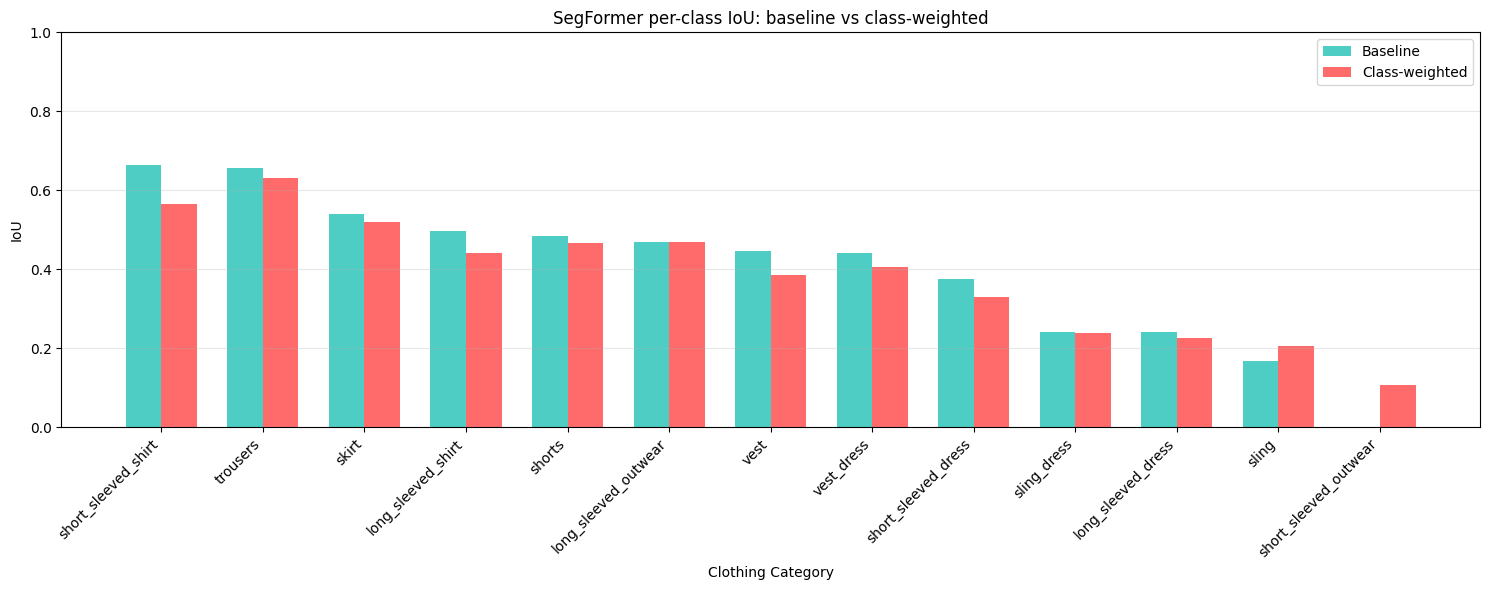


category                    baseline   weighted          Δ
short_sleeved_shirt           0.6643     0.5667    -0.0976
trousers                      0.6562     0.6317    -0.0245
skirt                         0.5414     0.5205    -0.0209
long_sleeved_shirt            0.4971     0.4403    -0.0568
shorts                        0.4839     0.4663    -0.0176
long_sleeved_outwear          0.4698     0.4688    -0.0010
vest                          0.4460     0.3868    -0.0592
vest_dress                    0.4408     0.4073    -0.0335
short_sleeved_dress           0.3759     0.3288    -0.0471
sling_dress                   0.2424     0.2385    -0.0039
long_sleeved_dress            0.2422     0.2252    -0.0170
sling                         0.1675     0.2071    +0.0397
short_sleeved_outwear         0.0000     0.1066    +0.1066


In [ ]:
# ============================================================
# 5A: PER-CLASS IoU — BASELINE vs WEIGHTED
# ============================================================
import matplotlib.pyplot as plt

baseline_per_class = result_baseline['history'][-1]['per_class_iou']
weighted_per_class = result_weighted['history'][-1]['per_class_iou']

# Sort by frequency in train set (most common first); use baseline magnitude as proxy
order = sorted(CATEGORIES, key=lambda c: -baseline_per_class.get(c, 0))

x = np.arange(len(order))
width = 0.35

baseline_vals = [baseline_per_class.get(c, 0) or 0 for c in order]
weighted_vals = [weighted_per_class.get(c, 0) or 0 for c in order]
baseline_vals = [0 if (isinstance(v, float) and np.isnan(v)) else v for v in baseline_vals]
weighted_vals = [0 if (isinstance(v, float) and np.isnan(v)) else v for v in weighted_vals]

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width/2, baseline_vals, width, label="Baseline", color="#4ECDC4")
ax.bar(x + width/2, weighted_vals, width, label="Class-weighted", color="#FF6B6B")
ax.set_xlabel("Clothing Category")
ax.set_ylabel("IoU")
ax.set_title("SegFormer per-class IoU: baseline vs class-weighted")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/segformer_per_class.png", dpi=150)
plt.show()

# Print table
print(f"\n{'category':<25} {'baseline':>10} {'weighted':>10} {'Δ':>10}")
for c in order:
    b = baseline_per_class.get(c, float("nan"))
    w = weighted_per_class.get(c, float("nan"))
    d = (w - b) if (not np.isnan(b) and not np.isnan(w)) else float("nan")
    print(f"{c:<25} {b:>10.4f} {w:>10.4f} {d:>+10.4f}")


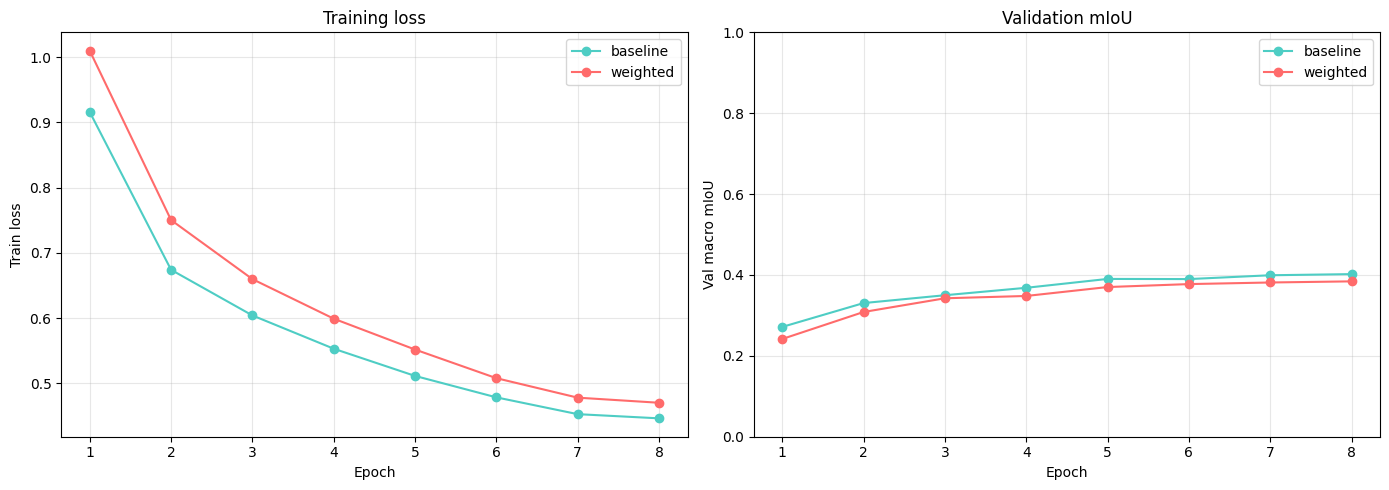

In [ ]:
# ============================================================
# 5B: TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, hist, color in [
    ("baseline", result_baseline["history"], "#4ECDC4"),
    ("weighted", result_weighted["history"], "#FF6B6B"),
]:
    epochs = [h["epoch"] for h in hist]
    losses = [h["train_loss"] for h in hist]
    mious  = [h["macro_miou"] for h in hist]
    axes[0].plot(epochs, losses, marker="o", label=label, color=color)
    axes[1].plot(epochs, mious,  marker="o", label=label, color=color)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss"); axes[0].set_title("Training loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val macro mIoU"); axes[1].set_title("Validation mIoU")
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("/content/segformer_training_curves.png", dpi=150)
plt.show()


🎨 Generating sample predictions...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


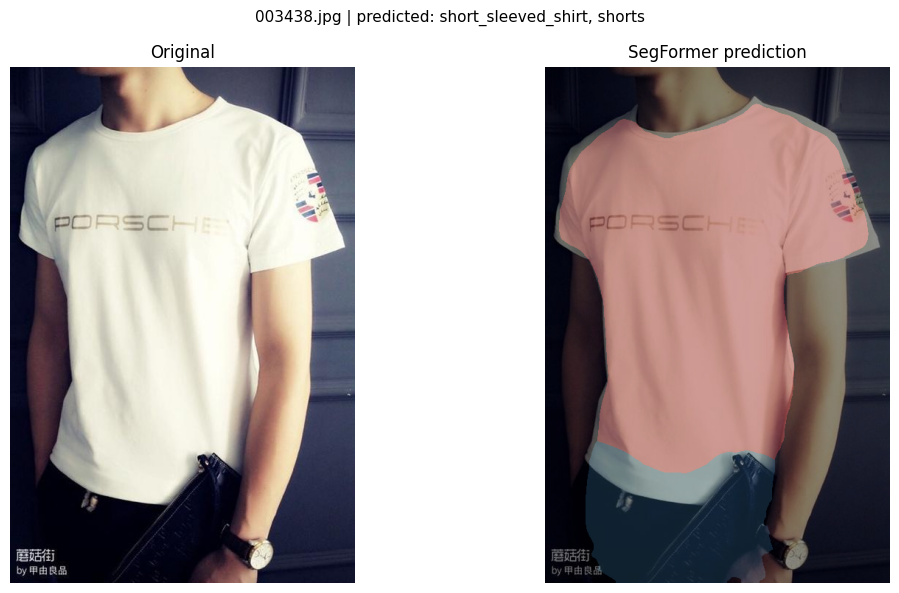

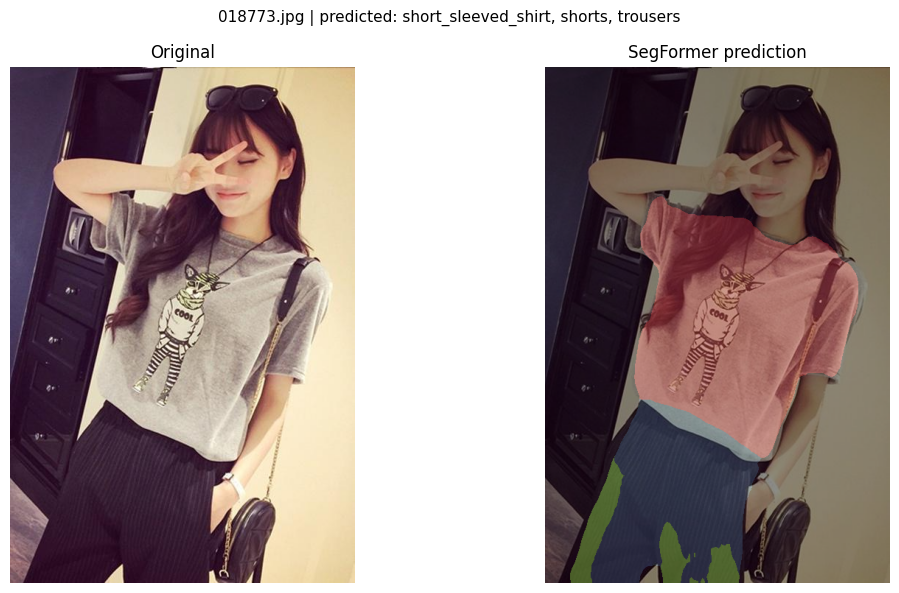

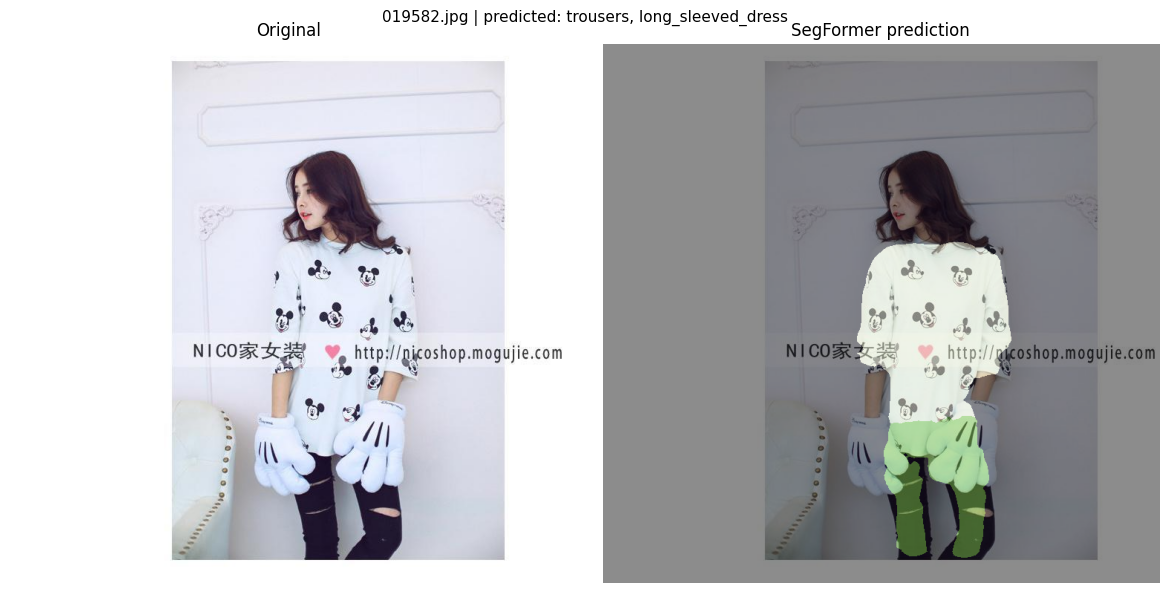

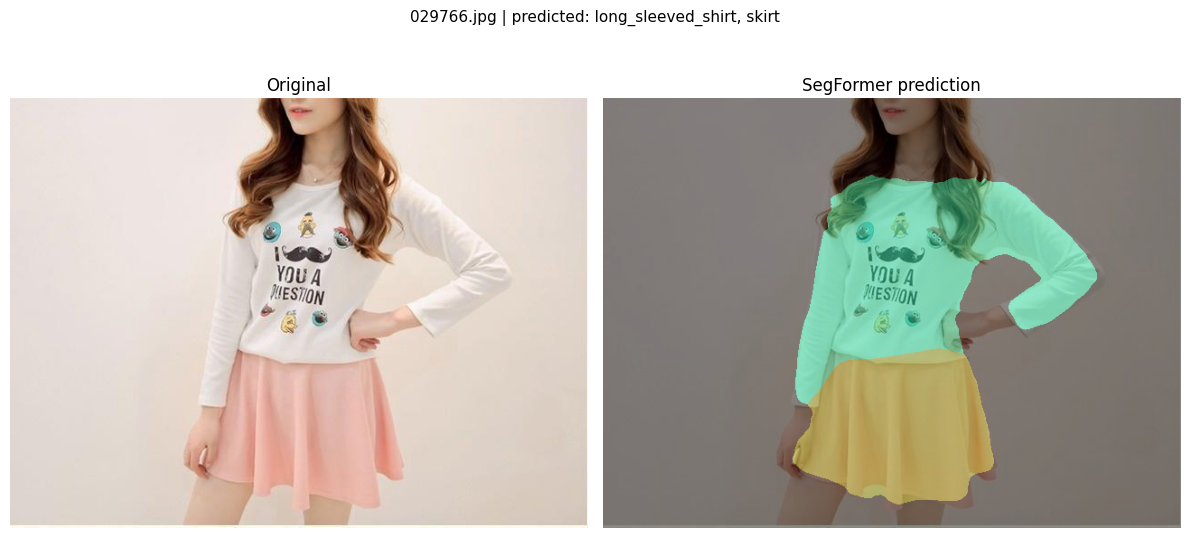

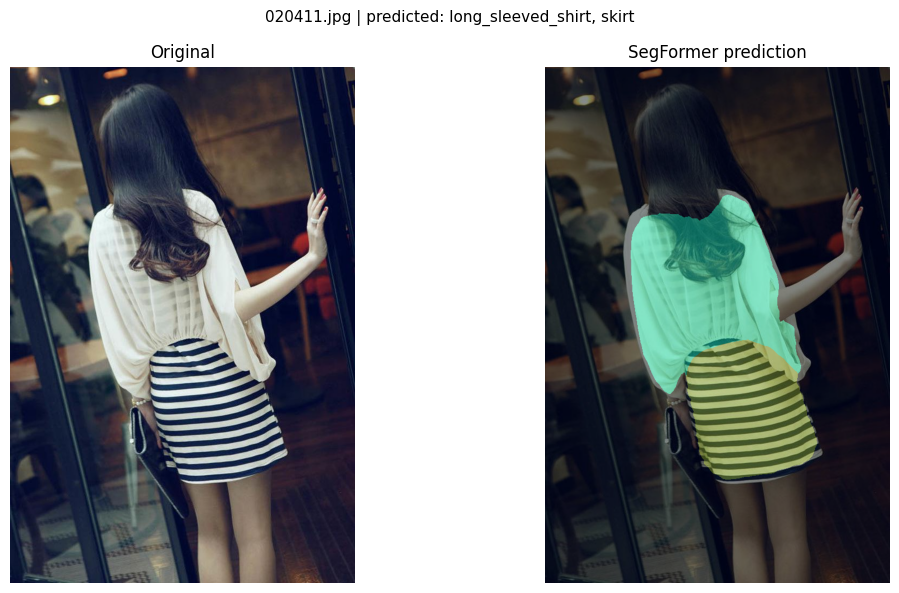


✅ Visual samples done


In [ ]:
# ============================================================
# 5C: QUALITATIVE SAMPLE PREDICTIONS
# ============================================================
import random
from transformers import SegformerConfig
print("🎨 Generating sample predictions...")

BEST_MODEL_PATH = result_weighted["run_dir"]

# Force-load the B2 architecture config we trained with (config.json may be incomplete)
config = SegformerConfig.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
)
sf_model = SegformerForSemanticSegmentation.from_pretrained(
    BEST_MODEL_PATH,
    config=config,
    ignore_mismatched_sizes=True,
).cuda().eval()
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"  # also pull from the original
)

with open(VAL_JSON) as f:
    val_data = json.load(f)
sample_imgs = random.sample(val_data["images"], min(5, len(val_data["images"])))

# Stable color per class
np.random.seed(42)
class_colors = (np.random.RandomState(42).rand(NUM_CLASSES, 3) * 255).astype(np.uint8)
class_colors[0] = [0, 0, 0]  # background = black

for img_info in sample_imgs:
    img_path = os.path.join(VAL_IMGS, img_info["file_name"])
    image = cv2.imread(img_path)
    if image is None:
        continue
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    inputs = processor(images=Image.fromarray(image_rgb), return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = sf_model(**inputs).logits
    pred = F.interpolate(logits, size=image_rgb.shape[:2],
                         mode="bilinear").argmax(dim=1).squeeze().cpu().numpy()

    color_map = class_colors[pred]
    blended = (image_rgb * 0.55 + color_map * 0.45).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image_rgb); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(blended);   axes[1].set_title("SegFormer prediction"); axes[1].axis("off")
    # Legend of classes present
    present = sorted(set(int(c) for c in np.unique(pred) if c != 0))
    if present:
        legend_text = ", ".join(CATEGORIES[c-1] for c in present)
        plt.suptitle(f"{img_info['file_name']} | predicted: {legend_text}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"/content/segformer_sample_{img_info['file_name']}", dpi=100)
    plt.show()

print("\n Visual samples done")


In [ ]:
# ============================================================
# 5D: SAVE EVERYTHING TO DRIVE
# ============================================================
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
dest = f"/content/drive/MyDrive/model_comparison/segformer_only_{timestamp}"
os.makedirs(dest, exist_ok=True)

# Trained model directories
shutil.copytree("/content/output_segformer", f"{dest}/runs", dirs_exist_ok=True)

# Charts
for f in ["segformer_per_class.png", "segformer_training_curves.png"]:
    src = f"/content/{f}"
    if os.path.exists(src):
        shutil.copy(src, dest)
for f in glob.glob("/content/segformer_sample_*.jpg") + glob.glob("/content/segformer_sample_*.png"):
    shutil.copy(f, dest)

# Results JSON
results_summary = {
    "baseline": {
        "best_macro_miou": result_baseline["best_macro_miou"],
        "final_per_class_iou": result_baseline["history"][-1]["per_class_iou"],
        "history": result_baseline["history"],
    },
    "weighted": {
        "best_macro_miou": result_weighted["best_macro_miou"],
        "final_per_class_iou": result_weighted["history"][-1]["per_class_iou"],
        "history": result_weighted["history"],
    },
}

def _sanitize(o):
    if isinstance(o, dict):  return {k: _sanitize(v) for k, v in o.items()}
    if isinstance(o, list):  return [_sanitize(x) for x in o]
    if isinstance(o, (int, float, str, type(None), bool)): return o
    return str(o)

with open(f"{dest}/segformer_results.json", "w") as f:
    json.dump(_sanitize(results_summary), f, indent=2)

print(f"\n All saved to: {dest}")
for item in os.listdir(dest):
    print(f"   - {item}")



✅ All saved to: /content/drive/MyDrive/model_comparison/segformer_only_20260512_0127
   - runs
   - segformer_per_class.png
   - segformer_training_curves.png
   - segformer_sample_020411.jpg
   - segformer_sample_003438.jpg
   - segformer_sample_019582.jpg
   - segformer_sample_018773.jpg
   - segformer_sample_029766.jpg
   - segformer_results.json


---
## 6. Cross-Model Integration (run AFTER Ronald uploads M2F + SAM results)

Combines SegFormer (this notebook), M2F (Ronald's notebook), and SAM (Ronald's
notebook) on the locked val subset into one comparison table.

**Prerequisites Ronald must upload to `Drive/CS_4701_project/`:**
- `m2f_results.json` — COCO results format from his M2F retrain
- `sam_results.json` — per-class IoU dict with format `{"per_class_iou": {...}, "mean_iou": float}`

In [ ]:
# ============================================================
# 6A: EVALUATE SEGFORMER ON LOCKED VAL SUBSET
# ============================================================
import json

SHARED_DIR = "/content/drive/MyDrive/CS4701"
with open(f"{SHARED_DIR}/val_subset.json") as f:
    val_ids_locked = set(json.load(f)["image_id_stems"])

# Pick the best run — usually weighted, switch to baseline if it won
BEST_SF_PATH = result_weighted["run_dir"]
print(f"Loading model from: {BEST_SF_PATH}")

from transformers import SegformerConfig

config = SegformerConfig.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
)
sf_model_locked = SegformerForSemanticSegmentation.from_pretrained(
    BEST_SF_PATH,
    config=config,
    ignore_mismatched_sizes=True,
).cuda().eval()
val_ds_locked = DeepFashionSegDataset(
    VAL_IMGS, VAL_MASKS,
    transform=get_val_transform(512),
    image_ids=val_ids_locked,
)

val_loader_locked = DataLoader(val_ds_locked, batch_size=16, shuffle=False,
                              num_workers=4, pin_memory=True)

sf_locked_results = evaluate_segformer(sf_model_locked, val_loader_locked, "cuda")
print(f"\n SegFormer macro mIoU on locked subset: {sf_locked_results['macro_miou']:.4f}")

Loading model from: /content/output_segformer/full_weighted


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

  Dataset: 2000 pairs from /content/deepfashion2_dataset/validation/validation/image



✅ SegFormer macro mIoU on locked subset: 0.3870


In [ ]:
# ============================================================
# 6B: LOAD RONALD'S M2F RESULTS AND COMPUTE PER-CLASS AP
# ============================================================
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

RONALD_M2F = f"{SHARED_DIR}/m2f_results.json"

if not os.path.exists(RONALD_M2F):
    print(f"  Not found: {RONALD_M2F}")
    print("    Waiting on Ronald to upload his M2F predictions.")
    m2f_locked_results = None
else:
    coco_gt = COCO(VAL_JSON)
    coco_dt = coco_gt.loadRes(RONALD_M2F)

    # Filter to locked subset
    stem_to_id = {os.path.splitext(coco_gt.imgs[i]["file_name"])[0]: i for i in coco_gt.imgs}
    keep_ids = sorted({stem_to_id[s] for s in val_ids_locked if s in stem_to_id})

    e = COCOeval(coco_gt, coco_dt, iouType="segm")
    e.params.imgIds = keep_ids
    e.evaluate(); e.accumulate(); e.summarize()

    precisions = e.eval["precision"]
    per_class_ap = {}
    for k, cat_id in enumerate(e.params.catIds):
        prec = precisions[:, :, k, 0, -1]
        prec = prec[prec > -1]
        ap = float(prec.mean()) if prec.size else float("nan")
        name = CATEGORIES[cat_id - 1] if 1 <= cat_id <= len(CATEGORIES) else f"cat_{cat_id}"
        per_class_ap[name] = ap

    m2f_locked_results = {"overall_ap": float(e.stats[0]), "per_class_ap": per_class_ap}
    print(f"\n M2F overall AP on locked subset: {m2f_locked_results['overall_ap']:.4f}")

In [ ]:
# ============================================================
# 6C: LOAD RONALD'S SAM RESULTS
# ============================================================
RONALD_SAM = f"{SHARED_DIR}/sam_results.json"

if not os.path.exists(RONALD_SAM):
    print(f" Not found: {RONALD_SAM}")
    print("    Waiting on Ronald to upload SAM IoU JSON.")
    sam_locked_results = None
else:
    with open(RONALD_SAM) as f:
        sam_locked_results = json.load(f)
    print(f" SAM mean IoU on locked subset: {sam_locked_results['mean_iou']:.4f}")

In [ ]:
# ============================================================
# 6D: UNIFIED PER-CATEGORY COMPARISON TABLE
# ============================================================
if m2f_locked_results is not None and sam_locked_results is not None:
    rows = [["category", "M2F_AP_segm", "SAM_IoU_gtbbox", "SegFormer_IoU"]]
    for cat in CATEGORIES:
        rows.append([
            cat,
            m2f_locked_results["per_class_ap"].get(cat, float("nan")),
            sam_locked_results["per_class_iou"].get(cat, float("nan")),
            sf_locked_results["per_class_iou"].get(cat, float("nan")),
        ])
    rows.append([
        "OVERALL",
        m2f_locked_results["overall_ap"],
        sam_locked_results["mean_iou"],
        sf_locked_results["macro_miou"],
    ])

    out_csv = f"{SHARED_DIR}/final_table.csv"
    out_md  = f"{SHARED_DIR}/final_table.md"

    with open(out_csv, "w") as f:
        for row in rows:
            f.write(",".join(f"{v:.4f}" if isinstance(v, float) else str(v)
                            for v in row) + "\n")
    with open(out_md, "w") as f:
        f.write("| " + " | ".join(rows[0]) + " |\n")
        f.write("|" + "|".join(["---"] * len(rows[0])) + "|\n")
        for row in rows[1:]:
            cells = [f"{v:.3f}" if isinstance(v, float) else str(v) for v in row]
            f.write("| " + " | ".join(cells) + " |\n")

    print(f" Wrote {out_csv}")
    print(f" Wrote {out_md}\n")

    # Print the table
    with open(out_md) as f:
        print(f.read())
else:
    print(" Cannot build table — waiting on Ronald's results.")
    print(f"    m2f_locked_results: {'✓' if m2f_locked_results else '✗ missing'}")
    print(f"    sam_locked_results: {'✓' if sam_locked_results else '✗ missing'}")

In [ ]:
# ============================================================
# 6E: PER-CLASS COMPARISON CHART
# ============================================================
import matplotlib.pyplot as plt

if m2f_locked_results is not None and sam_locked_results is not None:
    fig, ax = plt.subplots(figsize=(15, 6))
    x = np.arange(len(CATEGORIES))
    width = 0.27

    def _clean(d, key):
        vals = [d[key].get(c, 0) or 0 for c in CATEGORIES]
        return [0 if (isinstance(v, float) and np.isnan(v)) else v for v in vals]

    ax.bar(x - width, _clean(sam_locked_results, "per_class_iou"), width,
           label="SAM IoU (GT bbox)", color="#FF6B6B")
    ax.bar(x,         _clean(sf_locked_results, "per_class_iou"), width,
           label="SegFormer IoU", color="#4ECDC4")
    ax.bar(x + width, _clean(m2f_locked_results, "per_class_ap"), width,
           label="Mask2Former AP (segm)", color="#9B5DE5")

    ax.set_xlabel("Clothing Category")
    ax.set_ylabel("Score (note: AP and IoU are different metrics — see report)")
    ax.set_title("Per-Class Comparison Across Models on Locked Val Subset")
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORIES, rotation=45, ha="right")
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    out_png = f"{SHARED_DIR}/final_per_class_chart.png"
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f" Saved {out_png}")